In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print(X.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 16512
Testing Samples: 4128


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
svr = SVR(kernel='rbf')

svr.fit(X_train_scaled, y_train)

svr_pred = svr.predict(X_test_scaled)

print("Support Vector Regression Model Trained Successfully!")

Support Vector Regression Model Trained Successfully!


In [13]:
print("Support Vector Regression Performance")

print("MAE :", mean_absolute_error(y_test, svr_pred))
print("MSE :", mean_squared_error(y_test, svr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, svr_pred)))
print("R2 Score :", r2_score(y_test, svr_pred))

Support Vector Regression Performance
MAE : 0.3985990769520539
MSE : 0.3570040319338651
RMSE : 0.5974981438748284
R2 Score : 0.7275628923016773


In [14]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Regression Model Trained Successfully!")

Decision Tree Regression Model Trained Successfully!


In [15]:
print("Decision Tree Regression Performance")

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree Regression Performance
MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE : 0.7037294974840077
R2 Score : 0.622075845135081


In [16]:
comparison = pd.DataFrame({
    "Model": ["Support Vector Regression", "Decision Tree Regression"],
    "MAE": [
        mean_absolute_error(y_test, svr_pred),
        mean_absolute_error(y_test, dt_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, svr_pred),
        mean_squared_error(y_test, dt_pred)
    ],
    "R2 Score": [
        r2_score(y_test, svr_pred),
        r2_score(y_test, dt_pred)
    ]
})

comparison

,Model,MAE,MSE,R2 Score
0,Support Vector Regression,0.398599,0.357004,0.727563
1,Decision Tree Regression,0.454679,0.495235,0.622076


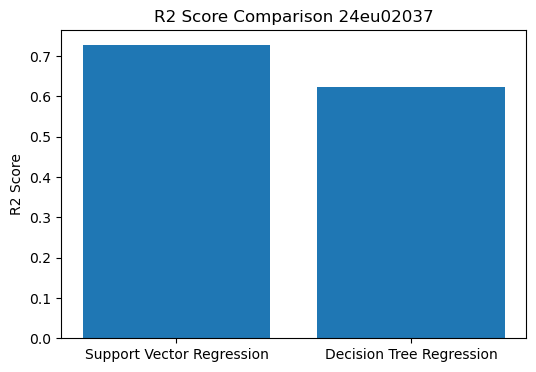

In [20]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("R2 Score Comparison 24eu02037")
plt.ylabel("R2 Score")

plt.show()

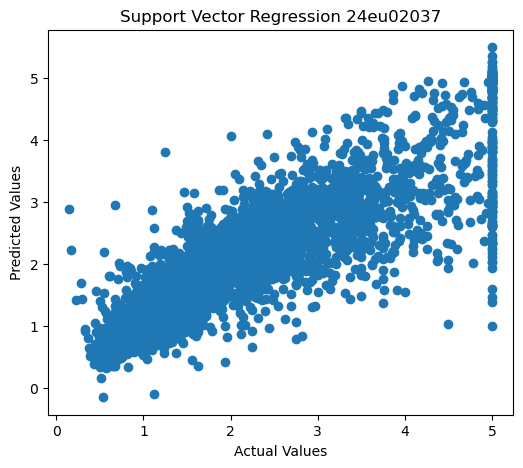

In [21]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, svr_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Support Vector Regression 24eu02037")

plt.show()

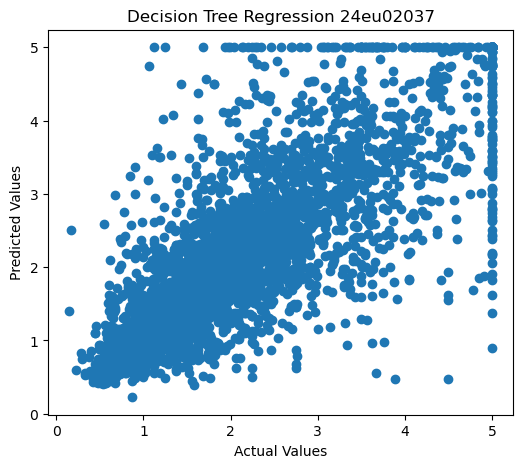

In [22]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, dt_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree Regression 24eu02037")

plt.show()